In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Damiano Degliotti, Daniele Melaccio

<h1>CUP - LinearSVR</h1>
<p>Exploring the cup dataset with LinearSVR.</p>
<hr/>

In [2]:
import importlib
import warnings
import numpy as np
from sklearn import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import cup_common as cc
import svm_common as sc
import cross_common as cr
from cross_common import MEE,MSE,RMSE,MAE,R2

In [3]:
importlib.reload(sc)
importlib.reload(cc)
importlib.reload(cr)

<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning, append=True)

<h2>Preparation</h2>

<h3>Hyperparameters</h3>

In [5]:
from sklearn.svm import LinearSVR

# We only test SVR
pipe_default = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", MultiOutputRegressor(LinearSVR())),
])


param_grid_default = [
    {
        "model__estimator__C": np.logspace(-4, 3, 8),
        "model__estimator__loss": ["epsilon_insensitive"],
        "model__estimator__dual": [True],
        "model__estimator__max_iter": [20000]
    },
    {
        "model__estimator__C": np.logspace(-4, 3, 8),
        "model__estimator__loss": ["squared_epsilon_insensitive"],
        "model__estimator__dual": [True, False],
        "model__estimator__max_iter": [20000]
    }
]

# --- The metrics to compute in training ---
metrics_dict = {
    MEE: (cr.mee, min),
    MSE: (cr.mse,min),
    MAE: (cr.mae,min),
    RMSE: (cr.rmse,min),
    R2: (cr.r2,min),
}
the_metrics = metrics_dict.keys()
# ------------------------------------------


# Common scoring
default_metric = MEE
scoring = cr.common_scoring(default_metric)

# Common CV fold strategy
outer_cv = cr.common_fold_strategy()


<h3>Data Loading</h3>

In [6]:
df_train, df_test = cc.load_set()

# The train set used for model selection
X_ts, y_ts = cc.prepare_dataset(df_test)

# Split the 500 labelled samples:
# - 80% development set for model selection and cross-validation
# - 20% internal test set for the final independent assessment
(
    X_tr, y_tr, # The train set
    X_internal_ts, y_internal_ts # The internal test set
 ) = (
    # by default 'prepare for hold out' split into 80% - 20%
    cc.prepare_dataset_for_hold_out(df_train,random_state=cc.INTERNAL_TEST_RANDOM_STATE)
)

features_names = X_tr.columns
cr.dataset_introspection(X_tr, X_ts)

,Property,Training,Test
0,Number of samples,400,1000
1,Number of features,10,10
2,Class values,[],[]
3,Class balance,[],[]


<h3>Baseline</h3>

In [7]:
importlib.reload(cr)
model_baseline = cr.model_baseline(X_tr, y_tr, outer_cv)

----------------------------------------
Baseline: DummyRegressor()
Mean baseline: 35.44424819946289
Scorer: make_scorer(neg_mean_euclidean_error, greater_is_better=False, response_method='predict')
Raw scores: [-34.0255928  -36.09343338 -35.34489059 -35.34389114 -36.41343307]


<h3>Best Model</h3>

In [8]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Perform a grid search
gs = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = outer_cv,
    scoring = scoring,
    error_score="raise",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gs.fit(X_tr, y_tr)

best_estimator = gs.best_estimator_
best_model, best_params = cr.extract_best_pipeline_metrics_from_grid(gs)


cr.grid_introspection(gs)

Grid summary
----------------------------------------
Total model explored: 24  splits: 5
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 20000}
Best score: -25.189227310902833
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=20000)))])


<h3>Learning Curve</h3>
<p>This plot shows the evolution of training and cross-validation errors as the training set size increases. The learning curve helps assess whether the model suffers from underfitting or overfitting and whether performance is limited by model capacity or by intrinsic noise in the data.</p>

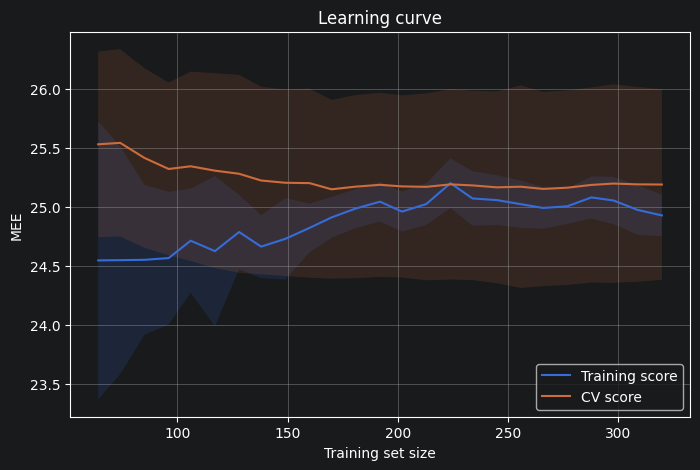

In [9]:
importlib.reload(cr)
cr.plot_learning_curve(best_estimator, X_tr, y_tr, outer_cv, scoring=scoring)

<h2>Model estimation</h2>
<p>The model is estimated trough two different approaches: non nested and nested KFold.</p>
<hr/>

<h3>Non nested Cross Validation</h3>

In [10]:
non_nested_runner = cr.SklearnRegressorRunner(gs)
non_nested_kf_result = cr.kfold(non_nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 23.7973
Validation MSE       | 176.3232
Validation MAE       | 10.8175
Validation RMSE      | 13.2787
Validation R2        | 0.3266
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 2, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 25.6225
Validation MSE       | 192.3248
Validation MAE       | 11.8168
Validation RMSE      | 13.8681
Validation R2        | 0.3310
Train                | samples: 320
Validation           | samples: 80
  
Perform fold: 3, train size: 320, val size: 80
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 24.9501
Validation MSE       | 182.9989
Validation MAE       | 11.3568
Validation RMSE 

In [11]:
best_idx = gs.best_index_
mean_score = gs.cv_results_["mean_test_score"][best_idx]
std_score  = gs.cv_results_["std_test_score"][best_idx]
print(f"Best CV grid score: {mean_score:.4f} ± {std_score:.4f}")
mean, std = cr.extract_mean_std(non_nested_kf_result, f"fold_vl_{default_metric}")
print(f"Best CV func score: {mean:.4f} ± {std:.4f}")

Best CV grid score: -25.1892 ± 0.8073
Best CV func score: 25.1892 ± 0.8073


<h3>Nested Cross Validation</h3>

In [12]:
importlib.reload(cr)

outer_cv = outer_cv
inner_cv = cr.common_fold_strategy(n_split=3)

gs_inner = GridSearchCV(
    pipe_default,
    param_grid=param_grid_default,
    scoring=scoring,
    cv=inner_cv,
    n_jobs=-1,
    return_train_score=True
)
nested_runner = cr.SklearnNestedRegressorRunner(gs_inner)
with warnings.catch_warnings():
    nested_result = cr.kfold(nested_runner, X_tr, y_tr, outer_cv, metrics=metrics_dict)

  
Perform fold: 1, train size: 320, val size: 80
Grid summary
----------------------------------------
Total model explored: 24  splits: 3
Best params: {'model__estimator__C': np.float64(0.01), 'model__estimator__dual': False, 'model__estimator__loss': 'squared_epsilon_insensitive', 'model__estimator__max_iter': 20000}
Best score: -25.631922501876335
Best model: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 MultiOutputRegressor(estimator=LinearSVR(C=np.float64(0.01),
                                                          dual=False,
                                                          loss='squared_epsilon_insensitive',
                                                          max_iter=20000)))])
 
Fold summary
--------------------------------------------------------------------------------
Validation MEE       | 23.7973
Validation MSE       | 176.3232
Validation MAE       | 10.8175
Validation RMSE      | 13.2787
Validation R2        

<h3>Results</h3>
<hr/>

<p>We expect that non nested KFold result has more optimistic metrics in respect to nested KFold.</p>

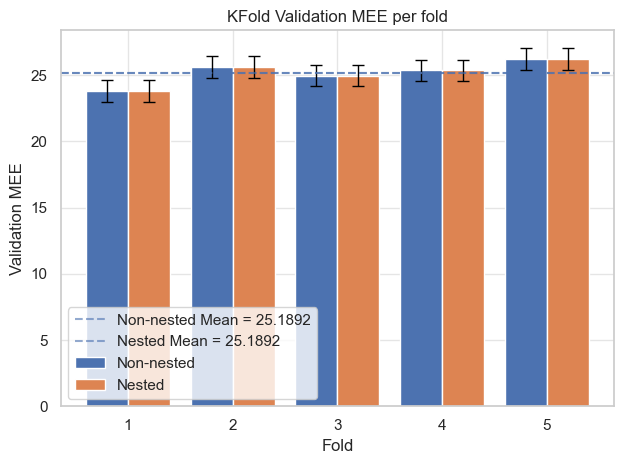

MEE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,25.241040,23.797304,-1.443736
2,24.802428,25.622510,0.820082
3,24.971122,24.950122,-0.021000
4,24.893206,25.364636,0.471430
5,24.729721,26.211565,1.481845
MEAN,24.927503,25.189227,0.261724
STD,0.176718,0.807254,0.983154


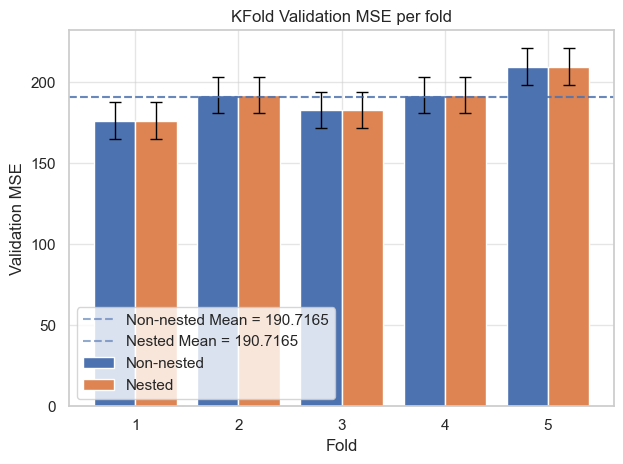

MSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,190.195570,176.323231,-13.872339
2,186.037594,192.324774,6.287180
3,188.276241,182.998860,-5.277381
4,186.392233,192.197431,5.805198
5,182.681033,209.738116,27.057082
MEAN,186.716534,190.716482,3.999948
STD,2.505505,11.254597,13.752158


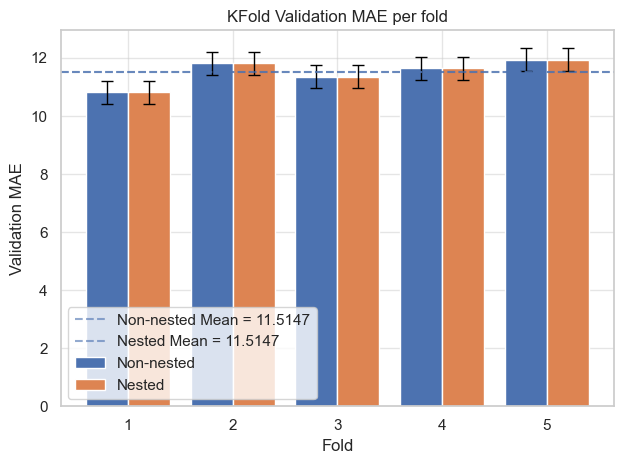

MAE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,11.558596,10.817549,-0.741046
2,11.308804,11.816837,0.508033
3,11.436708,11.356845,-0.079863
4,11.353737,11.648389,0.294652
5,11.309025,11.933806,0.624780
MEAN,11.393374,11.514685,0.121311
STD,0.094883,0.398935,0.493399


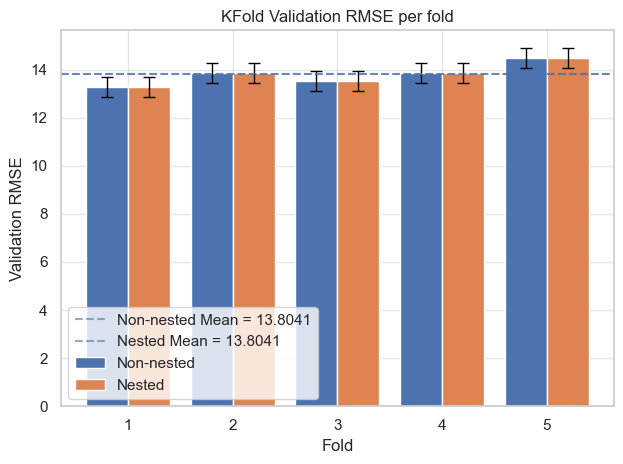

RMSE TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,13.791141,13.278676,-0.512465
2,13.639560,13.868121,0.228561
3,13.721379,13.527707,-0.193672
4,13.652554,13.863529,0.210975
5,13.515955,14.482338,0.966383
MEAN,13.664118,13.804074,0.139956
STD,0.091764,0.404994,0.496556


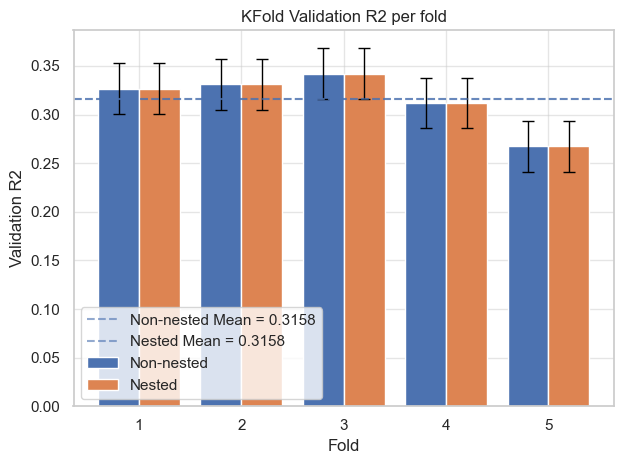

R2 TR vs VL from KFold Nested results


,TR,VL,|TR-VL|
Fold,,,
1,0.341543,0.326605,-0.014938
2,0.345599,0.331000,-0.014599
3,0.342717,0.342129,-0.000588
4,0.346933,0.311790,-0.035143
5,0.344888,0.267450,-0.077438
MEAN,0.344336,0.315795,-0.028541
STD,0.001953,0.026057,0.026815


In [13]:
for metric in the_metrics:
    cr.plot_kfold_metric([(non_nested_kf_result, "Non-nested"), (nested_result, "Nested")], metric)
    print(f"{metric.upper()} TR vs VL from KFold Nested results")
    display(cr.kfold_summary(nested_result, use=metric))

<h3>Bootstrap Variance</h3>
<p>Bootstrap is applied to approximate the sampling distribution of the estimator when only a finite dataset is available. By generating multiple resampled datasets, we can estimate variance, assess model stability, and better understand generalization behavior.</p>

In [14]:
importlib.reload(cr)
bootstrap_samples = 100
bootstrap_rstate = 42
samples = cr.generate_bootstrap_samples_from_dataset(X_tr, y_tr, n_samples=bootstrap_samples, random_state=bootstrap_rstate)
bootstrap_params = {"silence_output": True}

with warnings.catch_warnings():
    bootstrap_scores = cr.bootstrap_out_of_bag_scores(non_nested_runner, X_tr, y_tr, samples, metrics_dict,bootstrap_params=bootstrap_params)


In [15]:
importlib.reload(cr)
cr.aggregate_scores(bootstrap_scores)

,Metric,Mean,Std,%
0,R2,0.32,0.01,3.86
1,MSE,190.80,10.20,5.35
2,MEE,25.22,0.73,2.91
3,RMSE,13.81,0.37,2.68
4,MAE,11.52,0.36,3.14


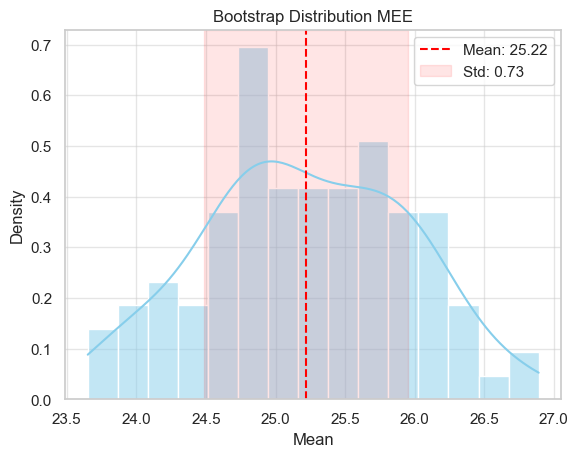

In [16]:
cr.plot_bootstrap_distribution([metric[default_metric] for metric in bootstrap_scores], title=f"Bootstrap Distribution {default_metric.upper()}")

<h2>Test predictions</h2>
<hr/>

In [17]:
fitted_model = non_nested_runner.fitted_model(X_tr, y_tr)

y_pred_tr = non_nested_runner.predict(fitted_model, X_tr)
y_pred_internal = non_nested_runner.predict(
    fitted_model,
    X_internal_ts,
)

mee_tr = cr.mee(y_tr, y_pred_tr)
mee_internal = cr.mee(y_internal_ts, y_pred_internal)

print(f"Training MEE:      {mee_tr:.4f}")
print(f"Internal Test MEE: {mee_internal:.4f}")


Training MEE:      24.9427
Internal Test MEE: 26.8403


<hr/>